In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score,accuracy_score,precision_score,recall_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [21]:
df=pd.read_csv("D:\\Github-Contributer-predictor\\src\\data\\processed\\github_contributor_dataset_N3_processed.csv")

In [22]:
categorical_features = ['author_association']
preprocessor=ColumnTransformer(transformers=[('cat',OneHotEncoder(),categorical_features)],
                               remainder='passthrough')

In [23]:
X = df.drop(columns=["user.id", "label"])
y = df["label"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [24]:
models={'LogisticRegression': LogisticRegression(),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBClassifier': XGBClassifier(random_state=42)}

In [25]:
for name,model in models.items():
    pipeline=Pipeline(steps=[("preprocessor",preprocessor),
                             ('feature_selection',SelectKBest(score_func=mutual_info_classif, k=4)),
                             ("classifier",model)])
    
    scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)
    print(f"Model: {name}")
    print(f"CV Mean F1: {scores.mean():.4f}")
    print(f"CV Std    : {scores.std():.4f}")
    print("-----------------------------------------------------")
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    print(f"Model: {name}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
    print(confusion_matrix(y_test, y_pred))
    print("-----------------------------------------------------")

Model: LogisticRegression
CV Mean F1: 0.7749
CV Std    : 0.0194
-----------------------------------------------------
Model: LogisticRegression
Accuracy : 0.5676
Precision: 0.6207
Recall   : 0.7826
F1 Score : 0.6923
[[ 3 11]
 [ 5 18]]
-----------------------------------------------------
Model: RandomForest
CV Mean F1: 0.7124
CV Std    : 0.0387
-----------------------------------------------------
Model: RandomForest
Accuracy : 0.6486
Precision: 0.7083
Recall   : 0.7391
F1 Score : 0.7234
[[ 7  7]
 [ 6 17]]
-----------------------------------------------------
Model: XGBClassifier
CV Mean F1: 0.7082
CV Std    : 0.0393
-----------------------------------------------------
Model: XGBClassifier
Accuracy : 0.6757
Precision: 0.6897
Recall   : 0.8696
F1 Score : 0.7692
[[ 5  9]
 [ 3 20]]
-----------------------------------------------------


In [26]:
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif)),
    ("classifier", LogisticRegression(max_iter=1000))
])

param_grid = {
    "feature_selection__k": [2, 3, 4, "all"],
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    log_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__C': 0.1, 'feature_selection__k': 2}
0.7934102950968308


In [27]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.6216216216216216
Precision: 0.6451612903225806
Recall   : 0.8695652173913043
F1       : 0.7407407407407407


In [28]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif)),
    ("classifier", XGBClassifier(random_state=42))
])

param_grid = {
    "feature_selection__k":[2,3,4,"all"],
    "classifier__n_estimators":[50,100,200],
    "classifier__max_depth":[3,5,7],
    "classifier__learning_rate":[0.01,0.1,0.2]
}

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__learning_rate': 0.01, 'classifier__max_depth': 7, 'classifier__n_estimators': 50, 'feature_selection__k': 'all'}
0.7898088589418826


In [30]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.6756756756756757
Precision: 0.6896551724137931
Recall   : 0.8695652173913043
F1       : 0.7692307692307693


Model explainability


In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


# Combine train and validation
X_train_final = pd.concat([X_train, X_val], axis=0)
y_train_final = pd.concat([y_train, y_val], axis=0)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif)),
    ("classifier", XGBClassifier(random_state=42))
])

param_grid = {
    "feature_selection__k":[2,3,4,"all"],
    "classifier__n_estimators":[50,100,200],
    "classifier__max_depth":[3,5,7],
    "classifier__learning_rate":[0.01,0.1,0.2]
}

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_final,y_train_final)
best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)
y_pred = grid.predict(X_test)
accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)
classification_report(y_test, y_pred)





{'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'feature_selection__k': 'all'}
0.7717699086796725


'              precision    recall  f1-score   support\n\n           0       0.67      0.29      0.40        14\n           1       0.68      0.91      0.78        23\n\n    accuracy                           0.68        37\n   macro avg       0.67      0.60      0.59        37\nweighted avg       0.67      0.68      0.63        37\n'

In [32]:
import shap

In [33]:
# Best pipeline
best_model = grid.best_estimator_

# Extract components
preprocessor = best_model.named_steps["preprocessor"]
selector = best_model.named_steps["feature_selection"]
xgb_model = best_model.named_steps["classifier"]

# Transform test data
X_test_preprocessed = preprocessor.transform(X_test)
X_test_selected = selector.transform(X_test_preprocessed)

# Get feature names
feature_names = preprocessor.get_feature_names_out()
selected_feature_names = feature_names[selector.get_support()]

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# SHAP values
shap_values = explainer(X_test_selected)

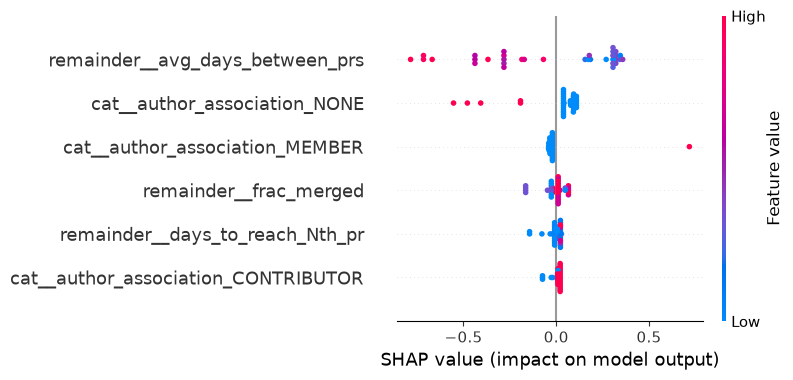

In [34]:
shap.summary_plot(
    shap_values,
    X_test_selected,
    feature_names=selected_feature_names
)

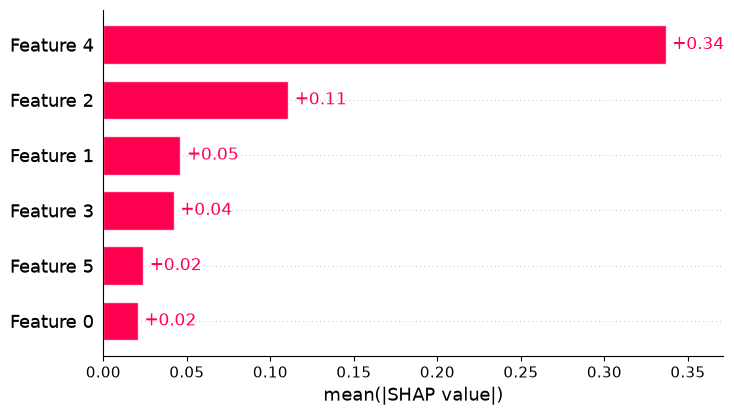

In [35]:
shap.plots.bar(shap_values)

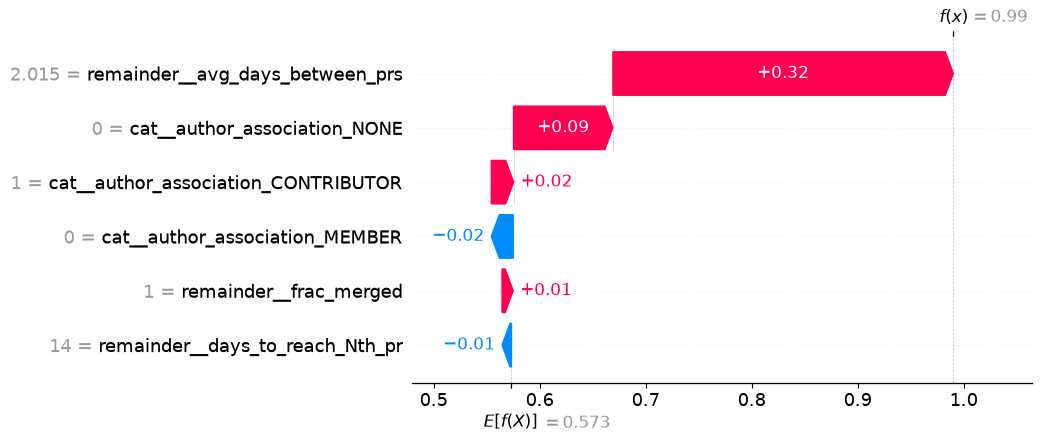

In [40]:
X_test_selected_df = pd.DataFrame(
    X_test_selected,
    columns=selected_feature_names
)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_selected_df)

shap.plots.waterfall(shap_values[0])

In [39]:
print(selected_feature_names)


['cat__author_association_CONTRIBUTOR' 'cat__author_association_MEMBER'
 'cat__author_association_NONE' 'remainder__frac_merged'
 'remainder__avg_days_between_prs' 'remainder__days_to_reach_Nth_pr']


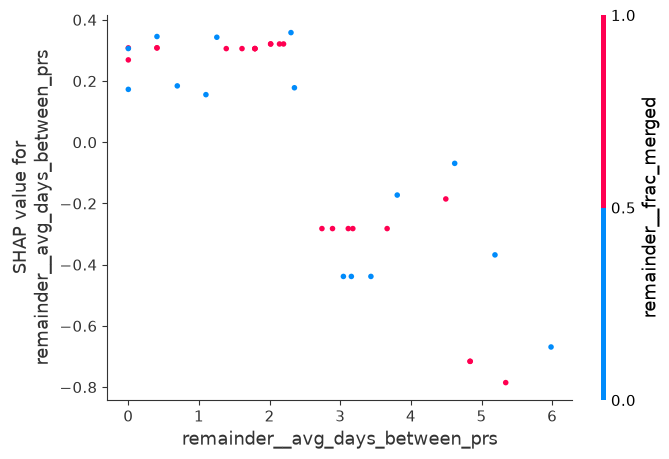

In [37]:
shap.dependence_plot(
    "remainder__avg_days_between_prs",
    shap_values.values,
    X_test_selected,
    feature_names=selected_feature_names
)

In [41]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/github_contributor_predictor.joblib")

['models/github_contributor_predictor.joblib']